# NASA CMAPSS FD001 — EDA & Feature Engineering Notebook
## Mission Readiness & Predictive Maintenance Hackathon

**Dataset:** Turbofan Engine Degradation Simulation (FD001)
- 100 training engines, 100 test engines
- Single operating condition, single fault mode: HPC Degradation
- 26 columns: unit_number, time_cycles, 3 op settings, 21 sensors

**Goal:** Build a clean, ML-ready dataset for RUL prediction + mission go/no-go logic.

---
**Run the script version instead:** `python cmapss_pipeline.py`

This notebook imports and calls each function from `cmapss_pipeline.py`
so you can inspect outputs cell-by-cell during demos.

In [4]:
# ─── Cell 0: Imports & Setup ──────────────────────────────────────────────
# All heavy lifting is in cmapss_pipeline.py; this notebook calls those
# functions one by one so judges can see results interactively.

import sys, os
import warnings
warnings.filterwarnings('ignore')

# Make sure the pipeline module is importable from this notebook's location
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
sys.path.insert(0, NOTEBOOK_DIR)

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')   # use 'inline' if running interactively in Jupyter
import matplotlib.pyplot as plt
import seaborn as sns

# Import all pipeline functions
from cmapss_pipeline import (
    load_data,
    analyze_cycle_structure,
    clean_and_smooth,
    extract_critical_sensors,
    compute_rul,
    apply_mission_window,
    normalize_and_export,
    write_eda_summary,
    COLUMNS, TOP_SENSORS, SENSORS_TO_DROP, RUL_CLIP,
    PLOTS_DIR, PROC_DIR
)

print('All imports successful!')
print(f'Plots will be saved to: {PLOTS_DIR}')
print(f'CSVs will be saved to:  {PROC_DIR}')

All imports successful!
Plots will be saved to: e:\BoB\bob-ai-hackathon-Astra\src\backend\data\processed\plots
CSVs will be saved to:  e:\BoB\bob-ai-hackathon-Astra\src\backend\data\processed


---
## Step 1 — Load Data
Parse raw space-separated text files, assign column names, run sanity checks.

In [5]:
# ─── Cell 1: Load ─────────────────────────────────────────────────────────
train_df, test_df, rul_df = load_data()

print('\nColumn names assigned:')
print(train_df.columns.tolist())
print('\nFirst 3 rows of training data:')
train_df.head(3)


STEP 1: LOADING DATA

TRAIN — shape: (20631, 26)
  dtypes:
unit_number       int64
time_cycles       int64
op_setting_1    float64
op_setting_2    float64
op_setting_3    float64
sensor_1        float64
sensor_2        float64
sensor_3        float64
sensor_4        float64
sensor_5        float64
sensor_6        float64
sensor_7        float64
sensor_8        float64
sensor_9        float64
sensor_10       float64
sensor_11       float64
sensor_12       float64
sensor_13       float64
sensor_14       float64
sensor_15       float64
sensor_16       float64
sensor_17         int64
sensor_18         int64
sensor_19       float64
sensor_20       float64
sensor_21       float64
  null counts: 0 total nulls
  describe:
        unit_number   time_cycles  op_setting_1  op_setting_2  op_setting_3  sensor_1      sensor_2      sensor_3      sensor_4      sensor_5      sensor_6      sensor_7      sensor_8      sensor_9  sensor_10     sensor_11     sensor_12     sensor_13     sensor_14     sensor

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442


---
## Step 2 — Engine Lifespan & Degradation Curves
Understand how long engines live and whether sensors visibly degrade.

In [6]:
# ─── Cell 2: Cycle Structure ───────────────────────────────────────────────
life_df = analyze_cycle_structure(train_df, test_df)
print('\nEngine lifespan DataFrame (first 5):')
life_df.head()


STEP 2: CYCLE STRUCTURE ANALYSIS

Engine lifespan stats (train):
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: max_cycle, dtype: float64

Shortest engine life : 128 cycles
Longest engine life  : 362 cycles
Mean engine life     : 206.3 cycles
  Plot saved -> e:\BoB\bob-ai-hackathon-Astra\src\backend\data\processed\plots\01_engine_lifespan_distribution.png
  Plot saved -> e:\BoB\bob-ai-hackathon-Astra\src\backend\data\processed\plots\02_sensor_degradation_curves.png

Engine lifespan DataFrame (first 5):


,unit_number,max_cycle
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


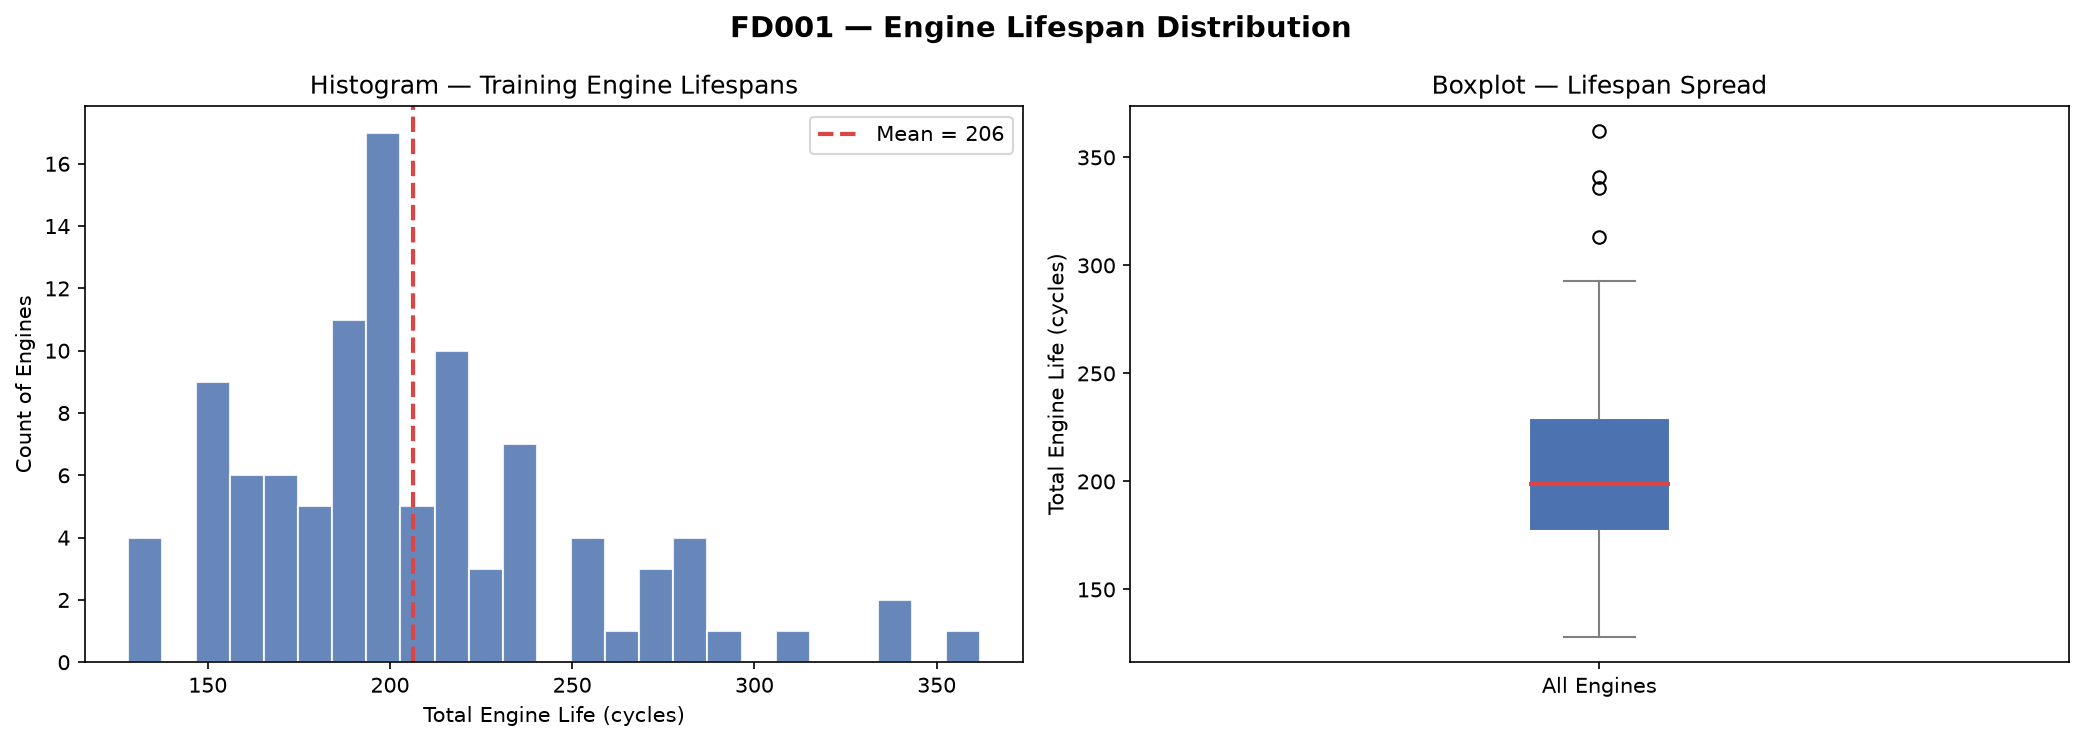

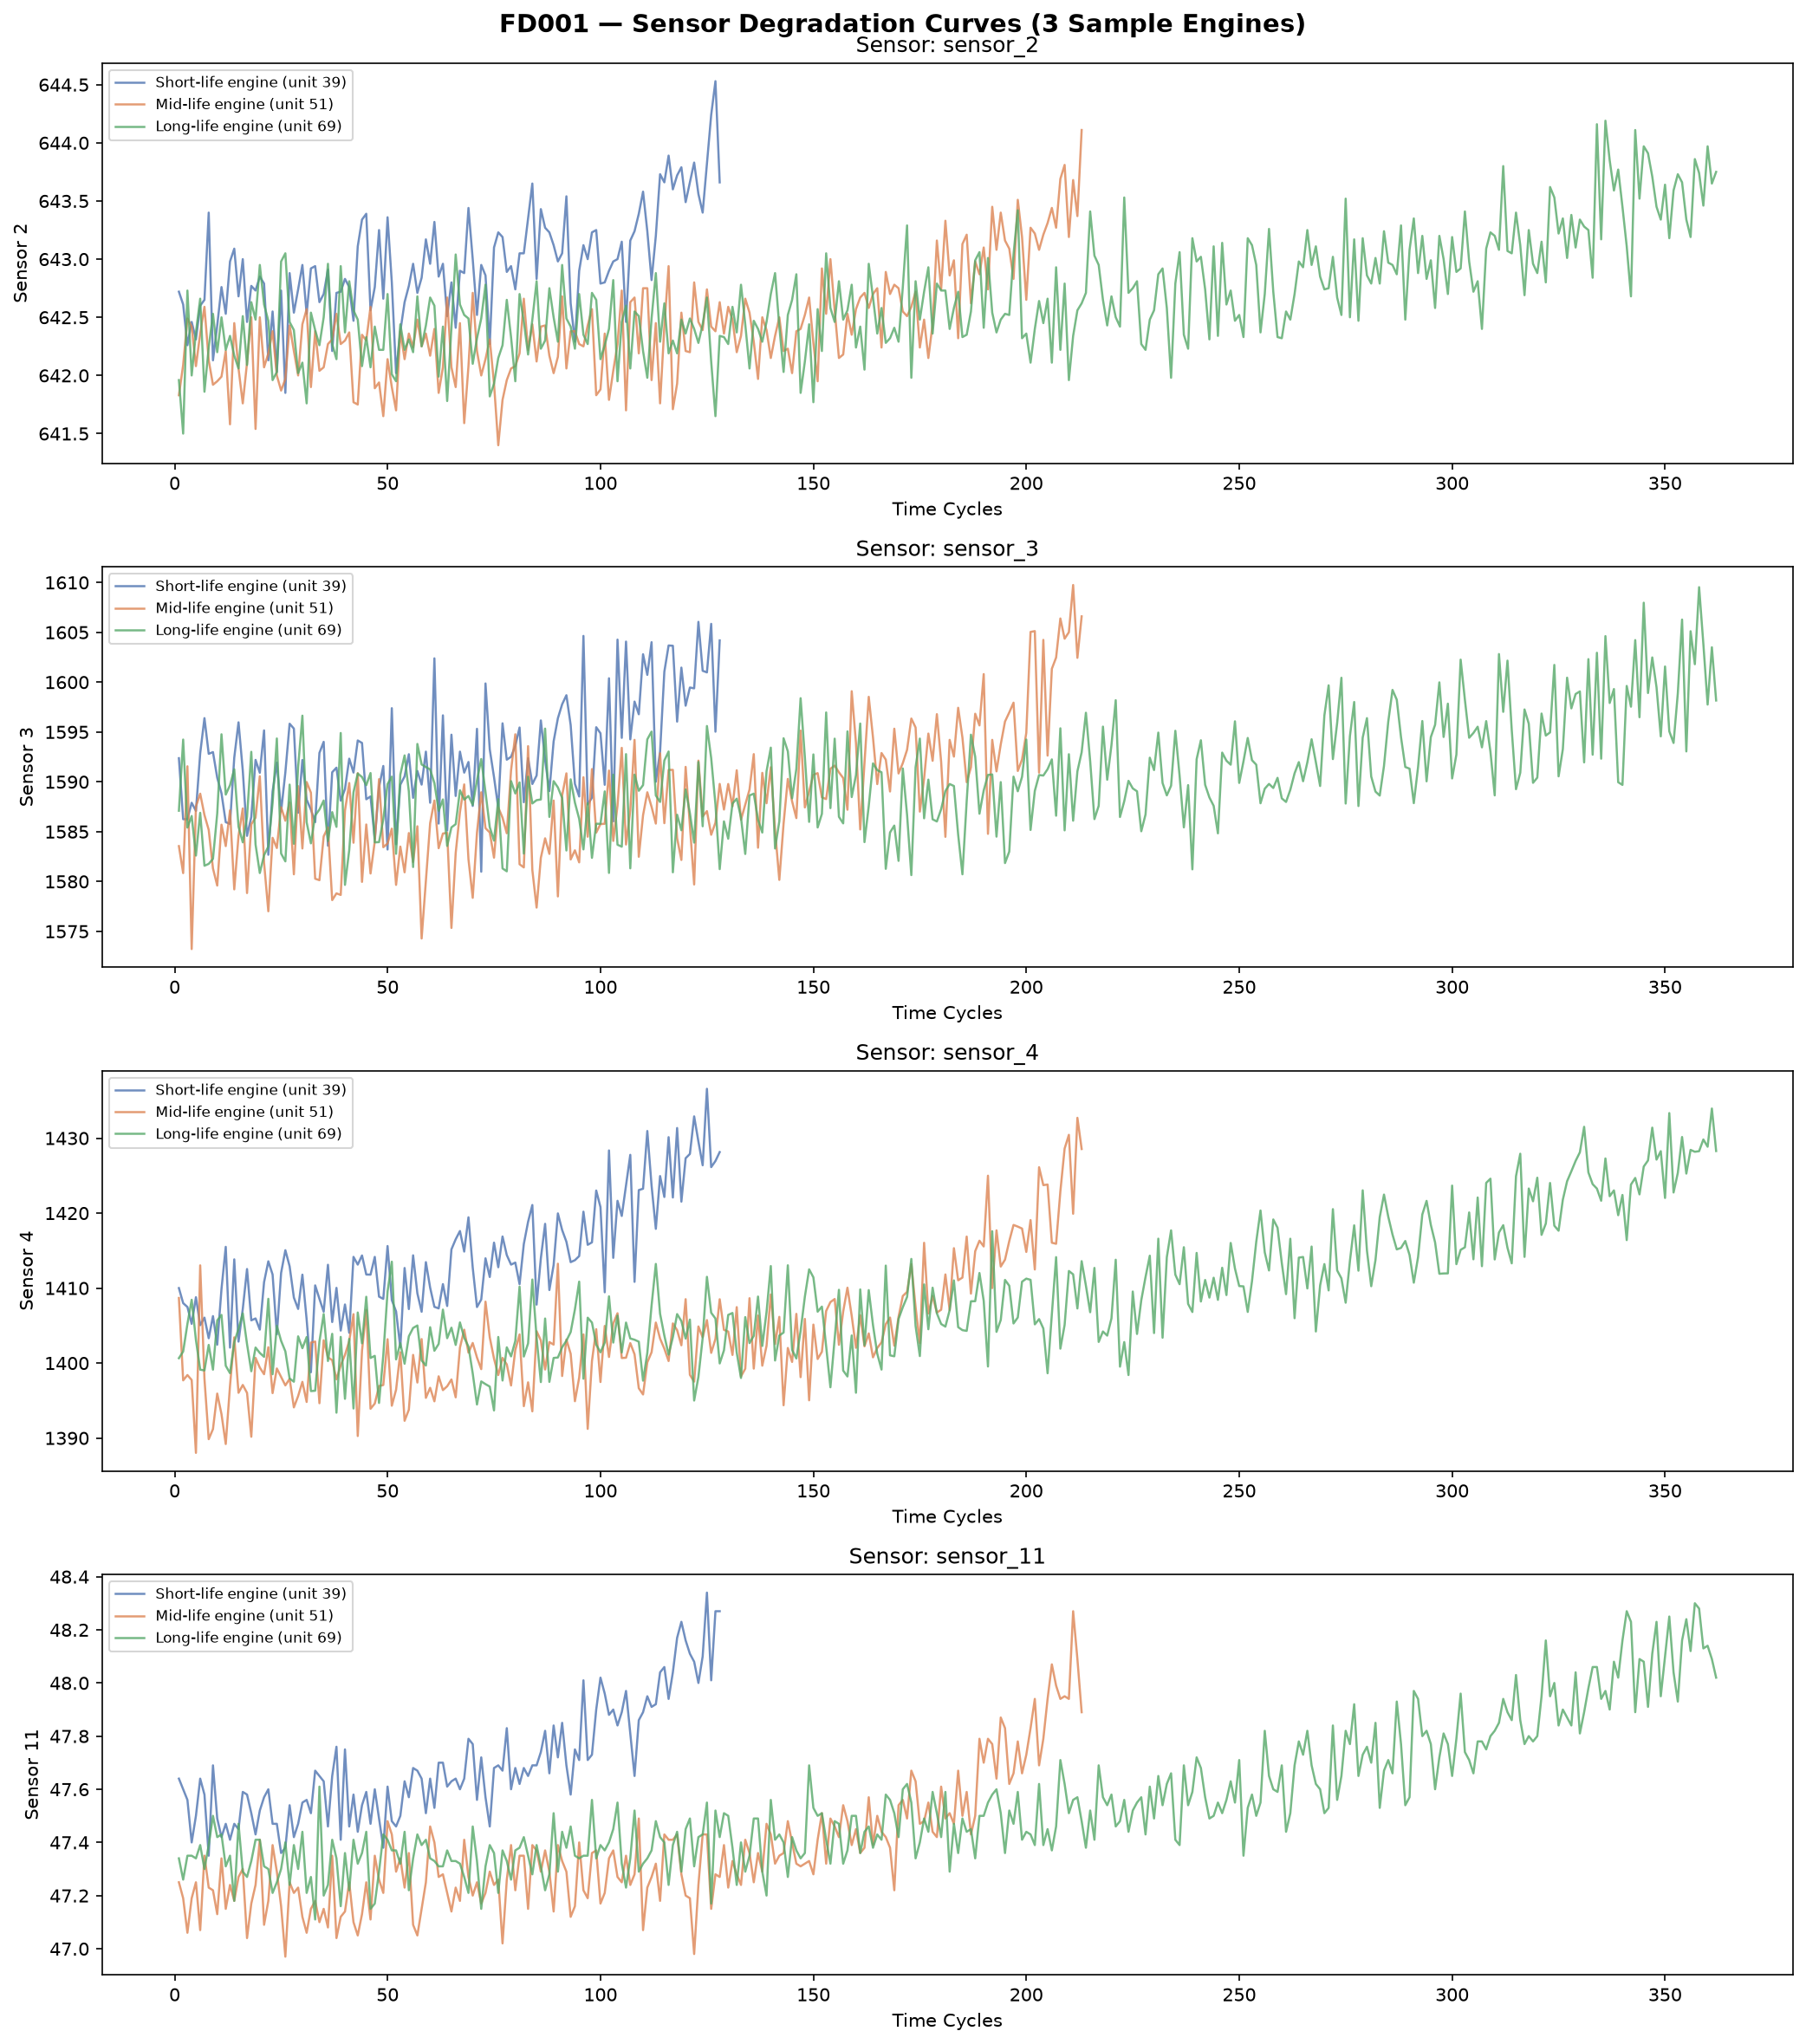

In [7]:
# ─── Cell 2b: Display saved plots inline ──────────────────────────────────
from IPython.display import Image, display
import os

for plot in ['01_engine_lifespan_distribution.png', '02_sensor_degradation_curves.png']:
    path = os.path.join(PLOTS_DIR, plot)
    if os.path.exists(path):
        display(Image(filename=path, width=900))
    else:
        print(f'Plot not found: {path}')

---
## Step 3 — Clean & Smooth
Identify useless constant sensors and apply rolling-window smoothing.

In [8]:
# ─── Cell 3: Clean & Smooth ────────────────────────────────────────────────
train_df, test_df, low_var_sensors = clean_and_smooth(train_df, test_df, window=5)

print(f'\nLow-variance sensors identified: {low_var_sensors}')
print(f'\nNew *_smooth columns added. Train shape: {train_df.shape}')
# Show a sample: raw vs smoothed for sensor_2
sample = train_df[train_df['unit_number']==1][['time_cycles','sensor_2','sensor_2_smooth']].head(10)
print('\nRaw vs Smoothed — unit 1, sensor_2:')
sample


STEP 3: CLEANING & SMOOTHING

Near-zero variance sensors (std < 0.01):
  op_setting_1          std = 0.002187
  op_setting_2          std = 0.000293
  op_setting_3          std = 0.000000
  sensor_1              std = 0.000000
  sensor_5              std = 0.000000
  sensor_6              std = 0.001389
  sensor_10             std = 0.000000
  sensor_16             std = 0.000000
  sensor_18             std = 0.000000
  sensor_19             std = 0.000000

These will be DROPPED: ['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Sensors retained for analysis: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
  Plot saved -> e:\BoB\bob-ai-hackathon-Astra\src\backend\data\processed\plots\03_sensor_variance.png

Rolling mean (window=5) applied to 14 sensors.
New columns added: 14 *_smooth columns
Train shape 

,time_cycles,sensor_2,sensor_2_smooth
0,1,641.82,641.820000
1,2,642.15,641.985000
2,3,642.35,642.106667
3,4,642.35,642.167500
4,5,642.37,642.208000
5,6,642.10,642.264000
6,7,642.48,642.330000
7,8,642.56,642.372000
8,9,642.12,642.326000
9,10,641.71,642.194000


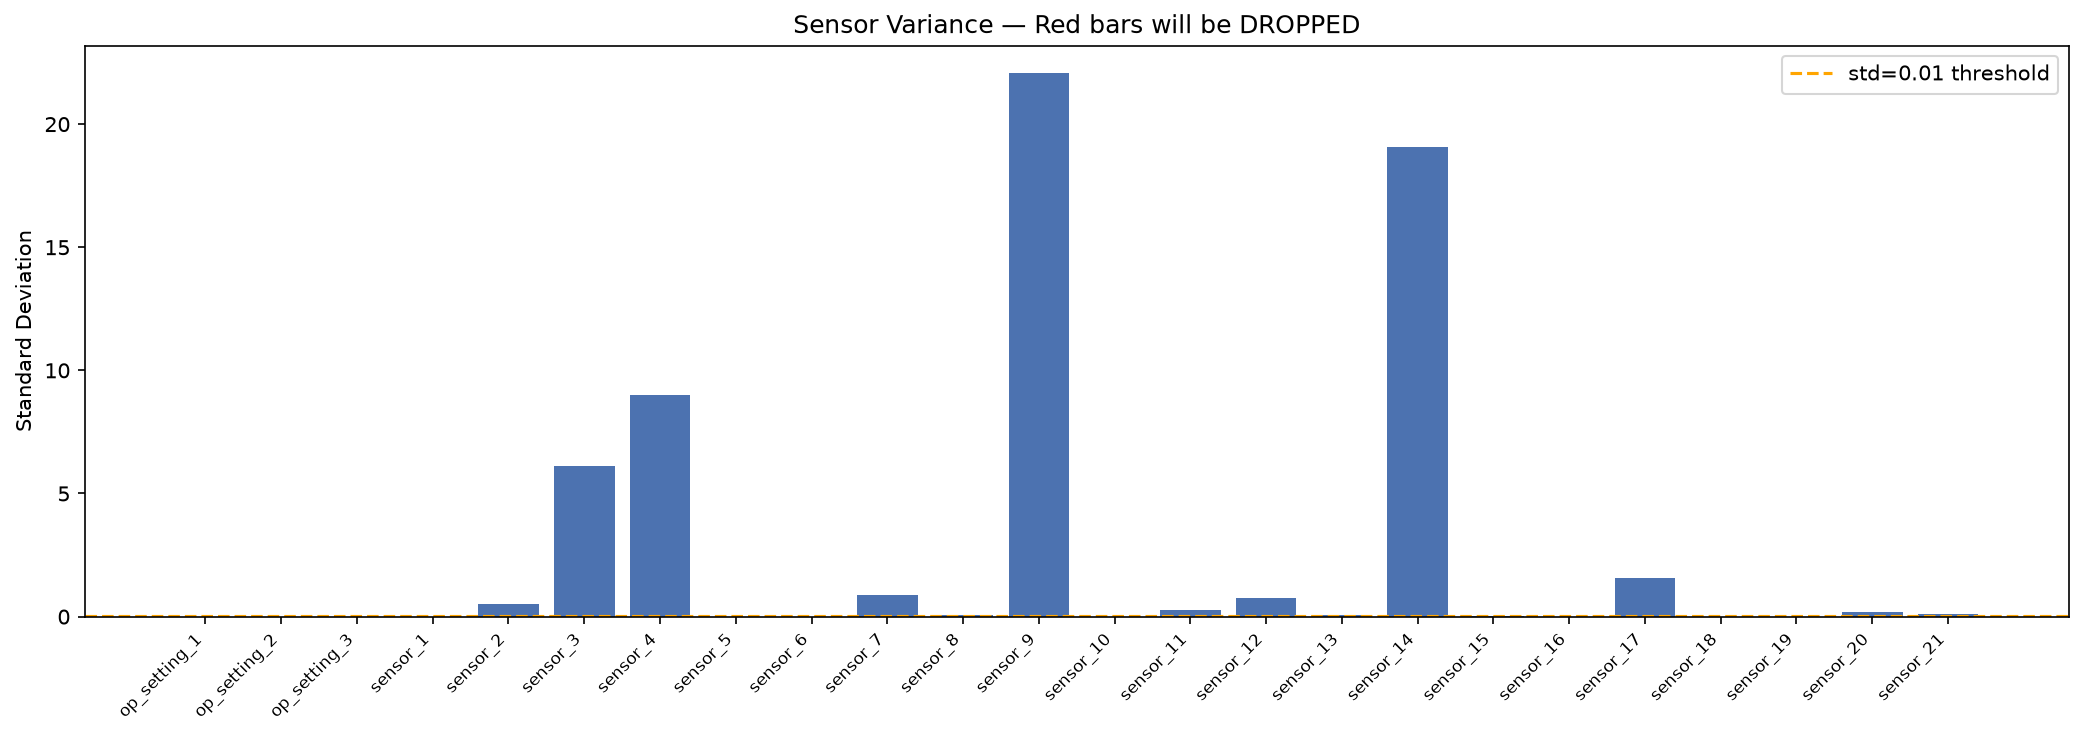

In [9]:
# Display variance plot inline
from IPython.display import Image, display
display(Image(filename=os.path.join(PLOTS_DIR, '03_sensor_variance.png'), width=900))

---
## Step 4 — Critical Sensor Extraction
Rank all sensors by correlation with RUL. Keep the top 14 most informative.

In [10]:
# ─── Cell 4: Feature Ranking ───────────────────────────────────────────────
sensor_rank = extract_critical_sensors(train_df, life_df)

print('\nTop 14 sensors by |correlation with RUL|:')
sensor_rank.nlargest(14, 'abs_corr_rul')[['sensor','corr_with_rul','corr_with_cycle']]


STEP 4: CRITICAL SENSOR EXTRACTION

Sensor ranking by |correlation with RUL|:
      sensor  corr_with_cycle  corr_with_rul  abs_corr_rul
   sensor_11     6.343845e-01  -6.962281e-01  6.962281e-01
    sensor_4     6.245772e-01  -6.789482e-01  6.789482e-01
   sensor_12    -6.113536e-01   6.719831e-01  6.719831e-01
    sensor_7    -5.959136e-01   6.572227e-01  6.572227e-01
   sensor_15     5.886758e-01  -6.426670e-01  6.426670e-01
   sensor_21    -5.859234e-01   6.356620e-01  6.356620e-01
   sensor_20    -5.835969e-01   6.294285e-01  6.294285e-01
    sensor_2     5.498980e-01  -6.064840e-01  6.064840e-01
   sensor_17     5.669949e-01  -6.061536e-01  6.061536e-01
    sensor_3     5.439470e-01  -5.845204e-01  5.845204e-01
    sensor_8     4.759773e-01  -5.639684e-01  5.639684e-01
   sensor_13     4.775230e-01  -5.625688e-01  5.625688e-01
    sensor_9     4.439993e-01  -3.901016e-01  3.901016e-01
   sensor_14     3.703236e-01  -3.067689e-01  3.067689e-01
    sensor_6     1.059800e-01  -1.28

,sensor,corr_with_rul,corr_with_cycle
13,sensor_11,-0.696228,0.634385
6,sensor_4,-0.678948,0.624577
14,sensor_12,0.671983,-0.611354
9,sensor_7,0.657223,-0.595914
17,sensor_15,-0.642667,0.588676
23,sensor_21,0.635662,-0.585923
22,sensor_20,0.629428,-0.583597
4,sensor_2,-0.606484,0.549898
19,sensor_17,-0.606154,0.566995
5,sensor_3,-0.584520,0.543947


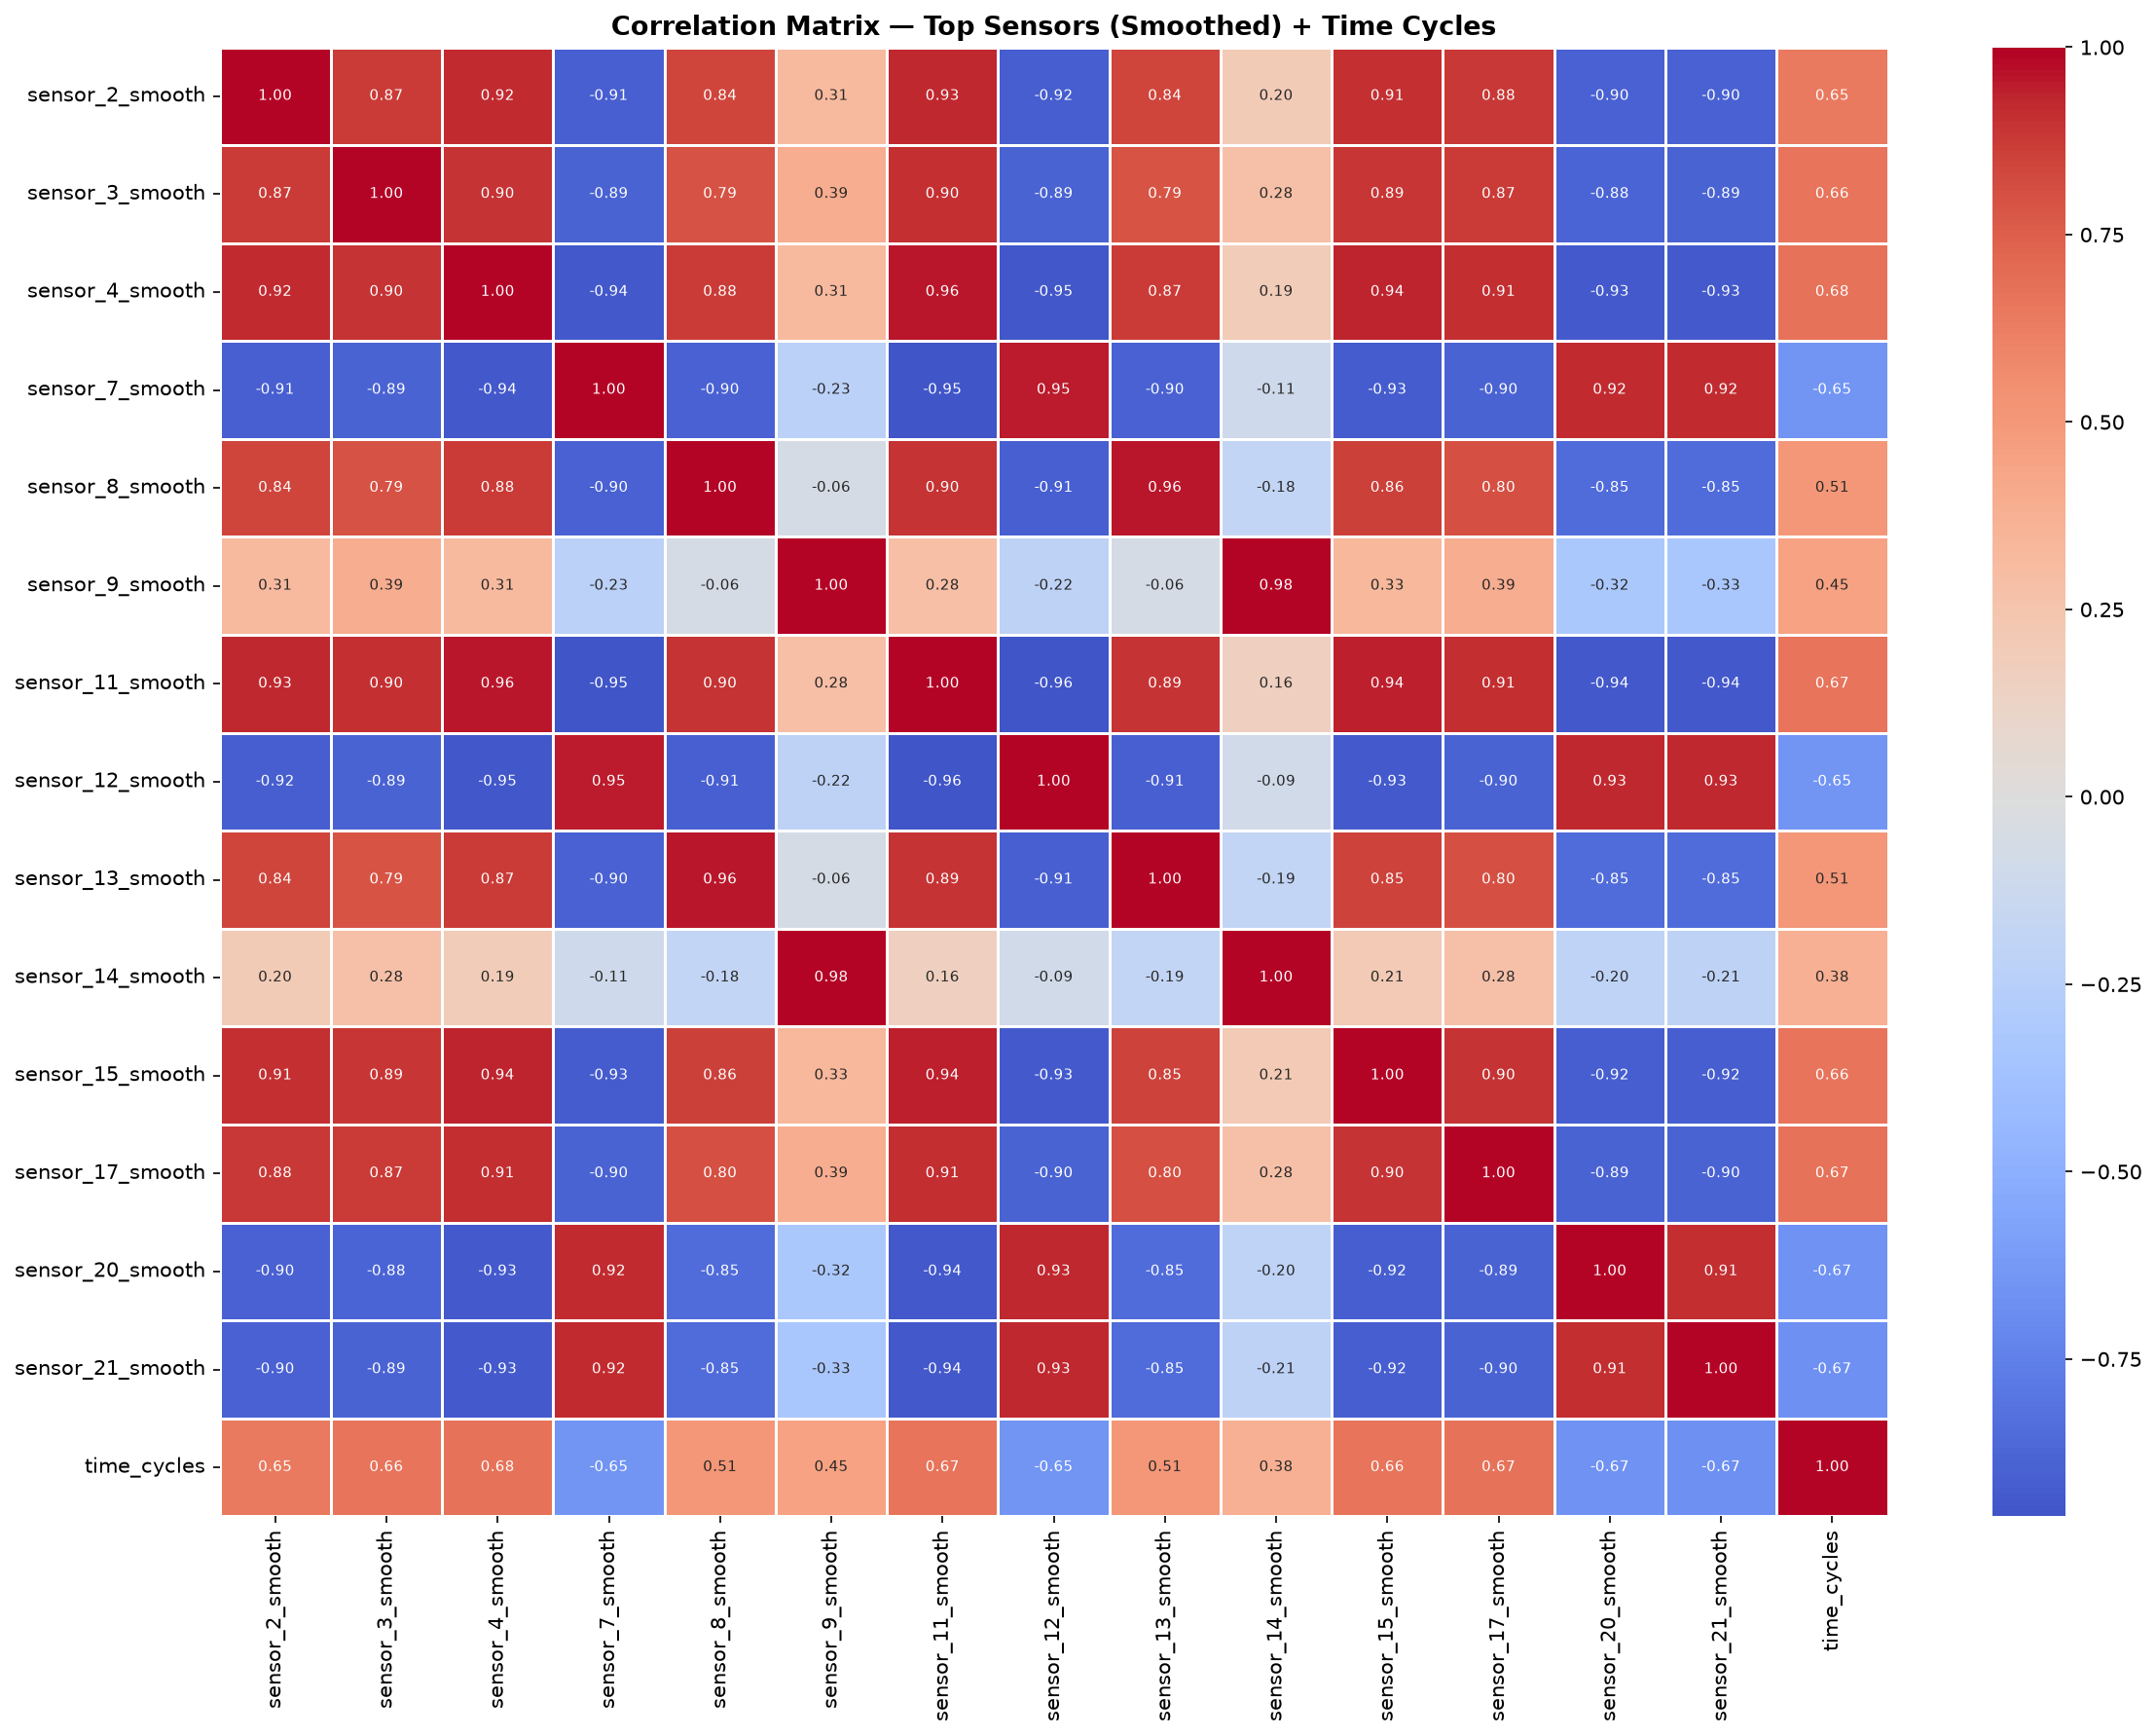

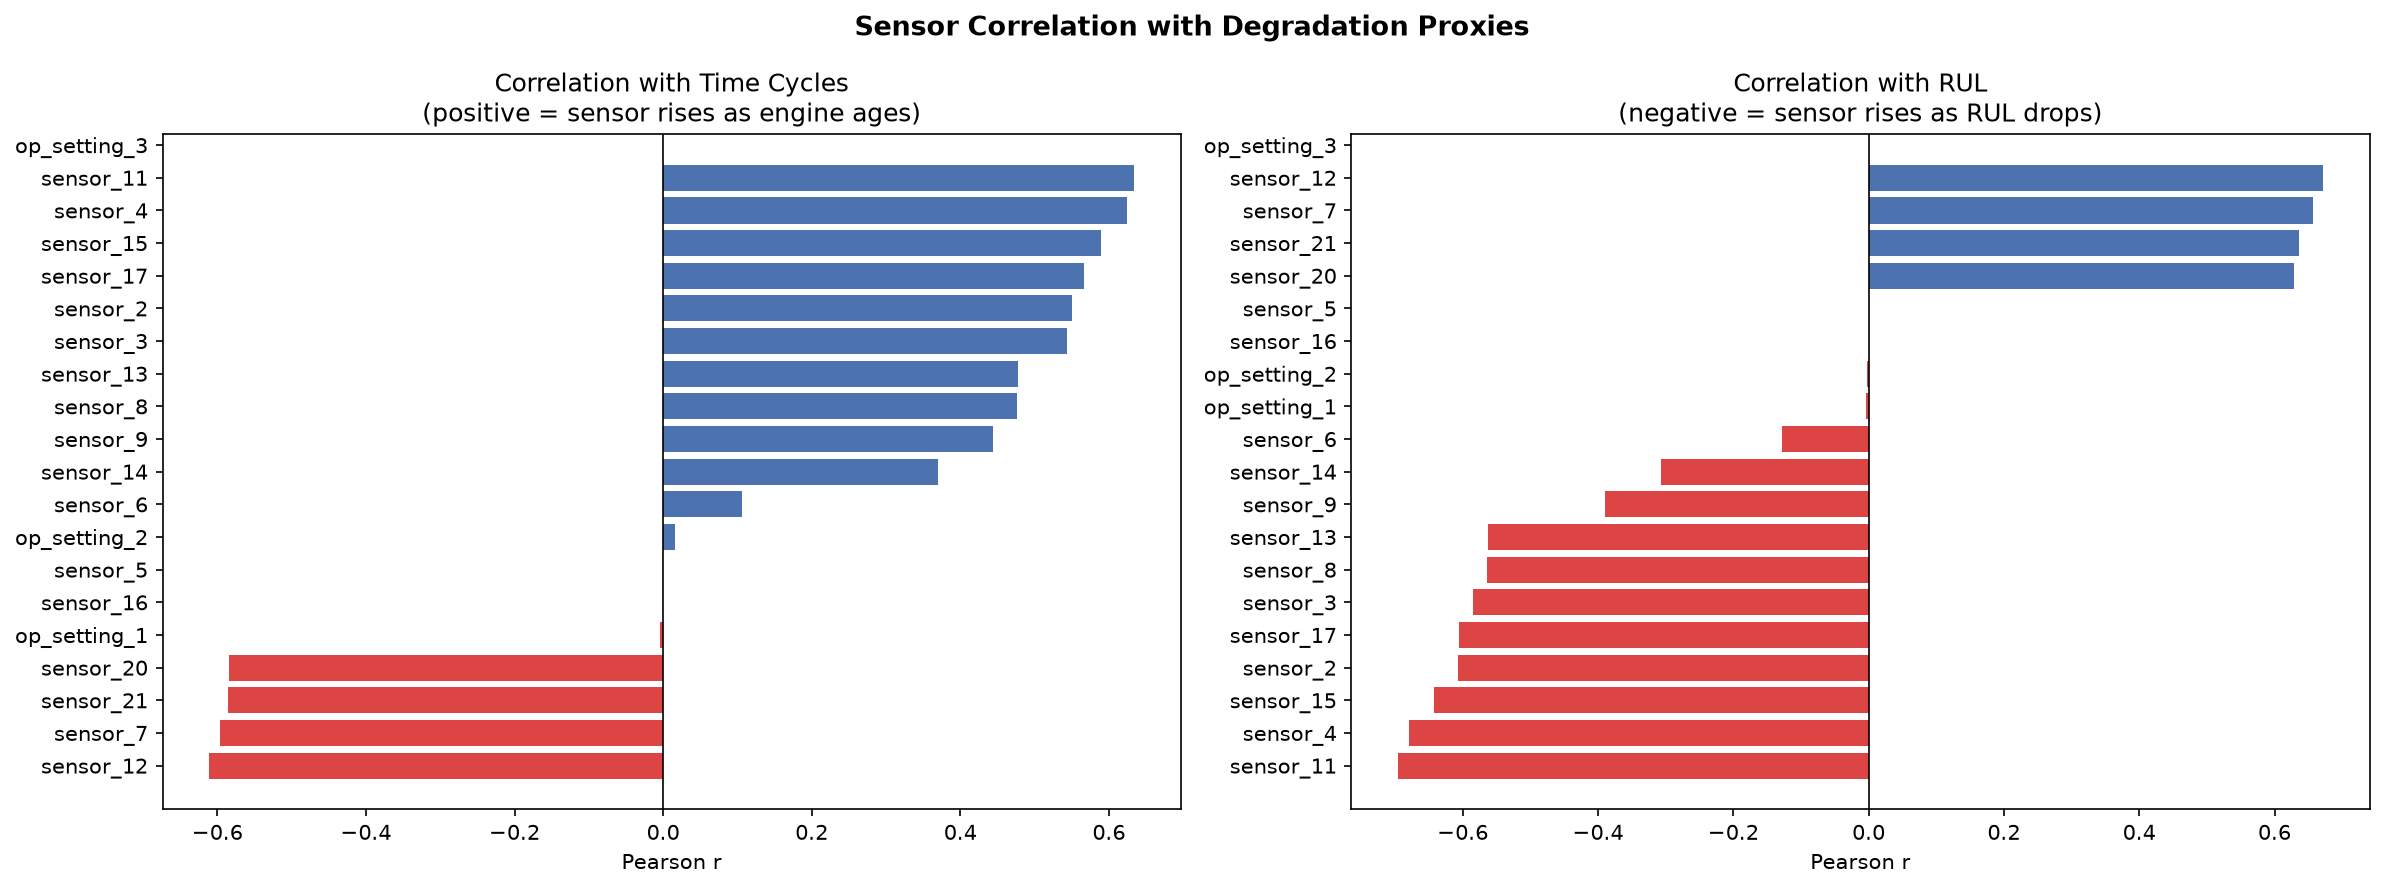

In [11]:
# Display correlation plots inline
from IPython.display import Image, display
for plot in ['04_sensor_correlation_heatmap.png', '05_sensor_rul_correlation_bars.png']:
    display(Image(filename=os.path.join(PLOTS_DIR, plot), width=900))

---
## Step 5 — RUL Computation
Training: ground-truth RUL from data. Test: back-calculated from RUL_FD001.txt.
Clip at 125 to focus model on the degradation window.

In [12]:
# ─── Cell 5: RUL ──────────────────────────────────────────────────────────
train_df, test_df = compute_rul(train_df, test_df, rul_df, life_df)

print('\nTrain RUL sample:')
train_df[['unit_number','time_cycles','rul','rul_clipped']].head(10)


STEP 5: RUL COMPUTATION
  Plot saved -> e:\BoB\bob-ai-hackathon-Astra\src\backend\data\processed\plots\06_rul_distribution.png

Training RUL stats (raw):
count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: rul, dtype: float64

Training RUL stats (clipped at 125):
count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: rul_clipped, dtype: float64

Test RUL stats (clipped at 125):
count    13096.000000
mean       108.919823
std         27.580258
min          7.000000
25%        102.000000
50%        125.000000
75%        125.000000
max        125.000000
Name: rul_clipped, dtype: float64

Train RUL sample:


,unit_number,time_cycles,rul,rul_clipped
0,1,1,191,125
1,1,2,190,125
2,1,3,189,125
3,1,4,188,125
4,1,5,187,125
5,1,6,186,125
6,1,7,185,125
7,1,8,184,125
8,1,9,183,125
9,1,10,182,125


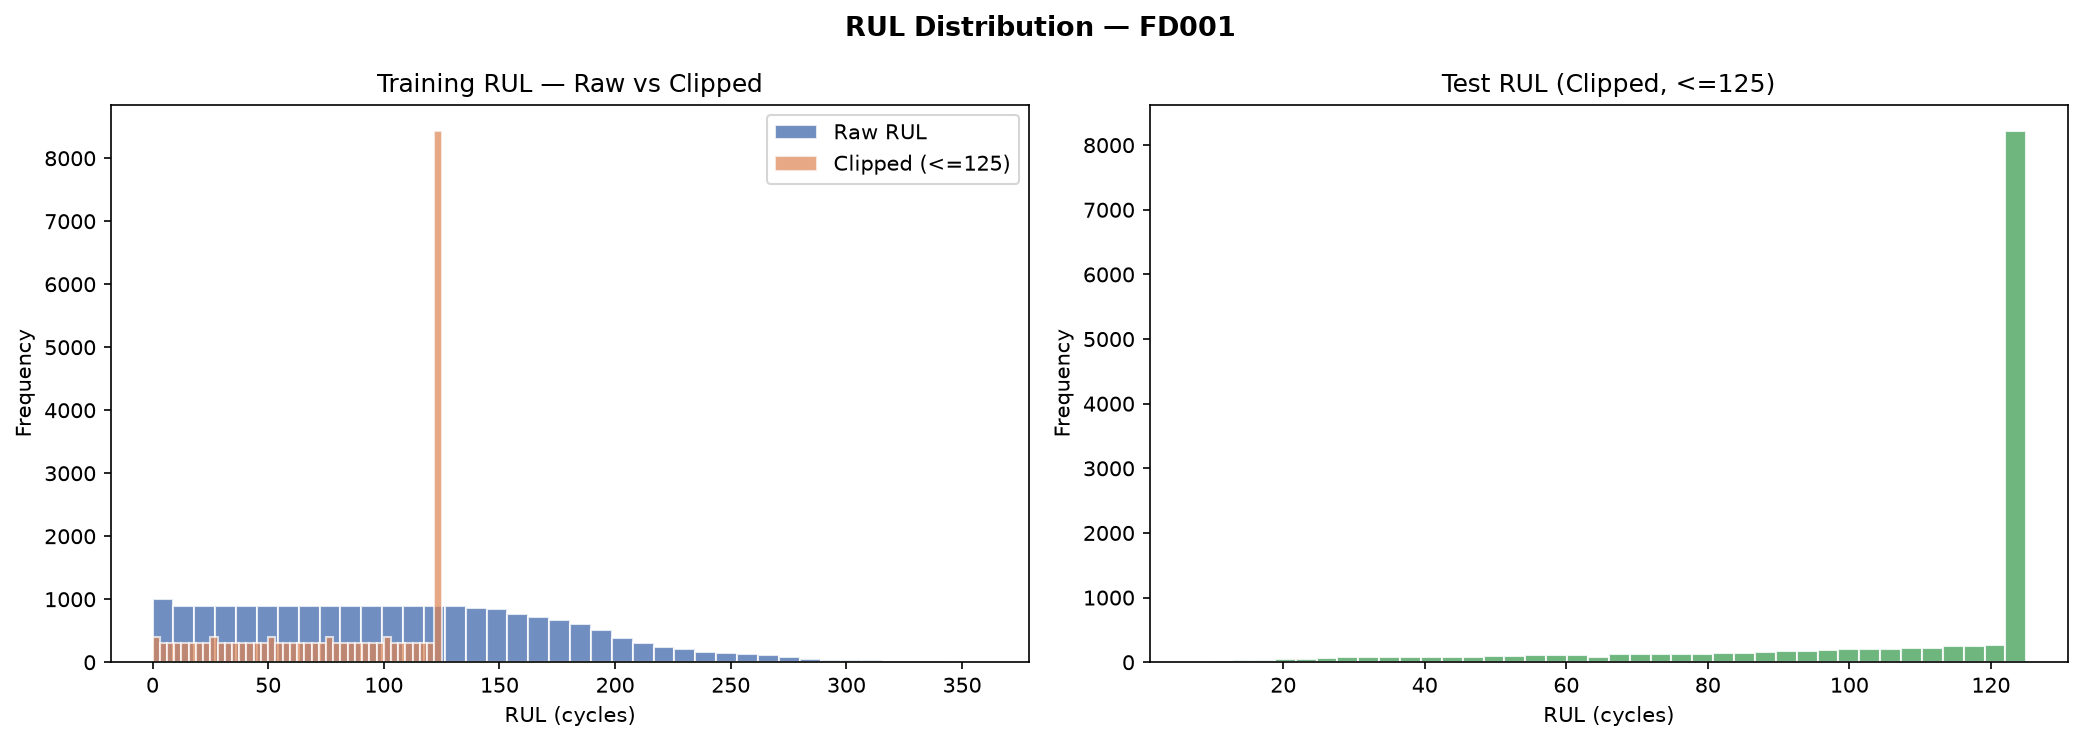

In [13]:
from IPython.display import Image, display
display(Image(filename=os.path.join(PLOTS_DIR, '06_rul_distribution.png'), width=900))

---
## Step 6 — Mission Window Logic
Core business logic: Can this engine survive the next mission?
**Change `MISSION_DURATION` below to test different fleet scenarios.**

In [14]:
# ─── Cell 6: Mission Window ────────────────────────────────────────────────
# Try 30, 45, 60 — or any value your backend config specifies per asset
MISSION_DURATION = 30.0

print(f'Applying mission window logic for mission_duration = {MISSION_DURATION} cycles...')

train_df = apply_mission_window(train_df, MISSION_DURATION)
test_df  = apply_mission_window(test_df,  MISSION_DURATION)

# Show critical risk examples from test set
print('\nSample critical-risk rows from test set:')
risk_rows = test_df[test_df['CRITICAL_OVERLAP_RISK']].tail(10)
risk_rows[['unit_number','time_cycles','rul_clipped',
           'predicted_failure_TTE','mission_duration','margin_of_safety','CRITICAL_OVERLAP_RISK']]

Applying mission window logic for mission_duration = 30.0 cycles...

  Mission duration     : 30.0 cycles
  Engines assessed     : 100
  CRITICAL RISK count  : 100  (100.0% fleet at risk)

  Mission duration     : 30.0 cycles
  Engines assessed     : 100
  CRITICAL RISK count  : 25  (25.0% fleet at risk)

Sample critical-risk rows from test set:


,unit_number,time_cycles,rul_clipped,predicted_failure_TTE,mission_duration,margin_of_safety,CRITICAL_OVERLAP_RISK
13086,100,189,29,29,30.0,-1.0,True
13087,100,190,28,28,30.0,-2.0,True
13088,100,191,27,27,30.0,-3.0,True
13089,100,192,26,26,30.0,-4.0,True
13090,100,193,25,25,30.0,-5.0,True
13091,100,194,24,24,30.0,-6.0,True
13092,100,195,23,23,30.0,-7.0,True
13093,100,196,22,22,30.0,-8.0,True
13094,100,197,21,21,30.0,-9.0,True
13095,100,198,20,20,30.0,-10.0,True


Plot saved: e:\BoB\bob-ai-hackathon-Astra\src\backend\data\processed\plots\08_mission_readiness_fleet.png


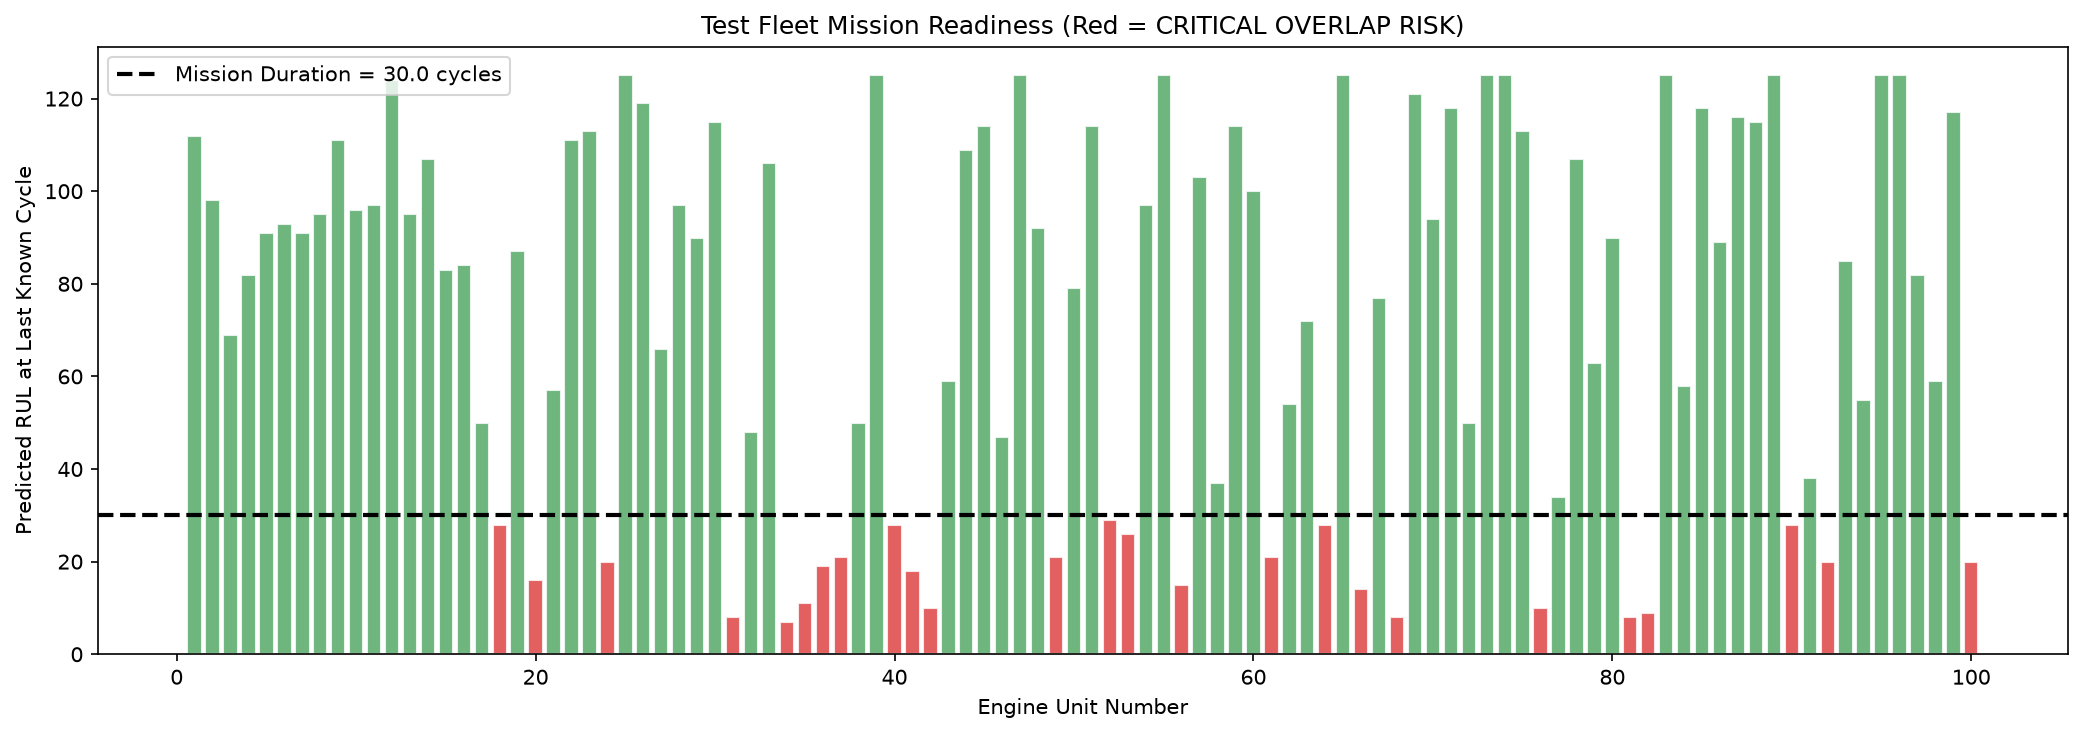

In [15]:
# ─── Cell 6b: Mission Readiness Quick Visualization ───────────────────────
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

# Plot last-cycle RUL vs mission duration for all test engines
last_cycle_test = test_df.groupby('unit_number').last().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#DD4444' if r else '#55A868' for r in last_cycle_test['CRITICAL_OVERLAP_RISK']]
ax.bar(last_cycle_test['unit_number'], last_cycle_test['rul_clipped'],
       color=colors, edgecolor='white', alpha=0.85)
ax.axhline(MISSION_DURATION, color='black', linestyle='--', linewidth=2,
           label=f'Mission Duration = {MISSION_DURATION} cycles')
ax.set_xlabel('Engine Unit Number')
ax.set_ylabel('Predicted RUL at Last Known Cycle')
ax.set_title('Test Fleet Mission Readiness (Red = CRITICAL OVERLAP RISK)')
ax.legend()
plt.tight_layout()

plot_path = os.path.join(PLOTS_DIR, '08_mission_readiness_fleet.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.close()
print(f'Plot saved: {plot_path}')

from IPython.display import Image, display
display(Image(filename=plot_path, width=900))

---
## Step 7 — Normalize & Export
Fit StandardScaler on training data only. Export CSVs + schema.json + scaler.pkl.

In [16]:
# ─── Cell 7: Export ────────────────────────────────────────────────────────
train_final, test_final = normalize_and_export(train_df, test_df, sensor_rank)

print('\nFinal training dataset shape:', train_final.shape)
print('Final test dataset shape:    ', test_final.shape)
print('\nFinal column list:')
print(train_final.columns.tolist())

print('\nSample training rows (scaled):')
train_final.head(5)


STEP 7: NORMALIZING & EXPORTING

Scaler saved -> e:\BoB\bob-ai-hackathon-Astra\src\backend\data\processed\scaler.pkl
Train ready CSV saved -> e:\BoB\bob-ai-hackathon-Astra\src\backend\data\processed\train_ready.csv  shape: (20631, 22)
Test  ready CSV saved -> e:\BoB\bob-ai-hackathon-Astra\src\backend\data\processed\test_ready.csv   shape: (13096, 22)
Schema JSON saved -> e:\BoB\bob-ai-hackathon-Astra\src\backend\data\processed\schema.json
  Plot saved -> e:\BoB\bob-ai-hackathon-Astra\src\backend\data\processed\plots\07_scaled_feature_distributions.png

Final training dataset shape: (20631, 22)
Final test dataset shape:     (13096, 22)

Final column list:
['unit_number', 'time_cycles', 'sensor_2_smooth', 'sensor_3_smooth', 'sensor_4_smooth', 'sensor_7_smooth', 'sensor_8_smooth', 'sensor_9_smooth', 'sensor_11_smooth', 'sensor_12_smooth', 'sensor_13_smooth', 'sensor_14_smooth', 'sensor_15_smooth', 'sensor_17_smooth', 'sensor_20_smooth', 'sensor_21_smooth', 'rul', 'rul_clipped', 'predicte

,unit_number,time_cycles,sensor_2_smooth,sensor_3_smooth,sensor_4_smooth,sensor_7_smooth,sensor_8_smooth,sensor_9_smooth,sensor_11_smooth,sensor_12_smooth,...,sensor_15_smooth,sensor_17_smooth,sensor_20_smooth,sensor_21_smooth,rul,rul_clipped,predicted_failure_TTE,mission_duration,margin_of_safety,CRITICAL_OVERLAP_RISK
0,1,1,-2.067769,-0.138150,-1.004816,1.228170,-0.544814,-0.894943,-0.258466,0.337071,...,-0.674506,-0.926028,1.564172,1.379118,191,125,125,30.0,95.0,False
1,1,2,-1.665516,0.079774,-0.846703,0.840998,-0.700981,-0.945843,-0.217596,0.800321,...,-0.482748,-0.926028,1.367661,1.404213,190,125,125,30.0,95.0,False
2,1,3,-1.368905,-0.110053,-0.750009,0.927742,-0.544814,-0.820833,-0.503688,1.024475,...,-0.564336,-1.453702,1.192984,1.123794,189,125,125,30.0,95.0,False
3,1,4,-1.220599,-0.472231,-0.774183,1.031411,-0.349605,-0.799865,-0.789780,1.300930,...,-0.991766,-1.321784,0.991014,1.064600,188,125,125,30.0,95.0,False
4,1,5,-1.121865,-0.687070,-0.680373,0.979365,-0.388647,-0.732830,-0.838824,1.266560,...,-0.866577,-1.084330,0.896034,1.095643,187,125,125,30.0,95.0,False


In [17]:
# Verify schema.json was written correctly
import json
schema_path = os.path.join(PROC_DIR, 'schema.json')
with open(schema_path) as f:
    schema = json.load(f)

print(f'Schema has {len(schema["columns"])} columns')
print('\nFirst 5 schema entries:')
for col in schema['columns'][:5]:
    print(f"  {col['name']:30s} | {col['pg_type']:20s} | {col['description']}")

Schema has 22 columns

First 5 schema entries:
  unit_number                    | INTEGER              | Engine/asset identifier (1-100 for FD001)
  time_cycles                    | INTEGER              | Operational cycle count at this measurement
  sensor_2_smooth                | DOUBLE PRECISION     | Smoothed, scaled reading of sensor 2
  sensor_3_smooth                | DOUBLE PRECISION     | Smoothed, scaled reading of sensor 3
  sensor_4_smooth                | DOUBLE PRECISION     | Smoothed, scaled reading of sensor 4


---
## Step 8 — EDA Summary Report

In [18]:
# ─── Cell 8: Write Summary ─────────────────────────────────────────────────
summary_path = write_eda_summary(
    train_df, test_df, life_df, sensor_rank,
    low_var_sensors, train_final, test_final
)
print(f'\nEDA Summary written to: {summary_path}')

# Print summary inline
with open(summary_path, 'r', encoding='utf-8') as f:
    from IPython.display import Markdown, display
    display(Markdown(f.read()))


STEP 8: WRITING EDA SUMMARY REPORT
EDA summary written -> e:\BoB\bob-ai-hackathon-Astra\src\backend\data\EDA_SUMMARY.md

EDA Summary written to: e:\BoB\bob-ai-hackathon-Astra\src\backend\data\EDA_SUMMARY.md


# EDA Summary — NASA CMAPSS FD001 Turbofan Degradation
*Mission Readiness & Predictive Maintenance Hackathon*
*Generated: 2026-09-14 20:30*

---

## 1. Dataset Overview

| Property | Value |
|---|---|
| Dataset | NASA CMAPSS — FD001 (single fault: HPC Degradation) |
| Training engines | 100 |
| Test engines | 100 |
| Training rows | 20,631 |
| Test rows | 13,096 |
| Raw columns | 26 (unit_number, time_cycles, 3 op settings, 21 sensors) |
| ML-ready columns | 22 |
| Operating condition | Single (FD001 has constant altitude/speed/throttle) |

Engine lifespans ranged from **128 to 362 cycles**
(mean approx 206 cycles). This is the operational window the model must cover.

---

## 2. Dropped Sensors & Why

The following sensors were **dropped** because they carry essentially zero variance in FD001.
A sensor that never changes cannot tell the model anything useful — it's pure noise overhead.

- `op_setting_3`
- `sensor_1`
- `sensor_5`
- `sensor_6`
- `sensor_10`
- `sensor_16`
- `sensor_18`
- `sensor_19`

> **Note:** `op_setting_3` is always `100.0` in FD001 (single operating condition).
> Sensors 1, 5, 6, 10, 16, 18, 19 are physically constant for this fault mode.

---

## 3. Top Predictive Sensors

These 14 sensors showed the strongest correlation with **Remaining Useful Life (RUL)**
and were retained as features (after smoothing + scaling):

| Sensor | Corr w/ RUL | Corr w/ Cycle |
|--------|-------------|---------------|
| sensor_11       | -0.696 | +0.634 |
| sensor_4        | -0.679 | +0.625 |
| sensor_12       | +0.672 | -0.611 |
| sensor_7        | +0.657 | -0.596 |
| sensor_15       | -0.643 | +0.589 |
| sensor_21       | +0.636 | -0.586 |
| sensor_20       | +0.629 | -0.584 |
| sensor_2        | -0.606 | +0.550 |
| sensor_17       | -0.606 | +0.567 |
| sensor_3        | -0.585 | +0.544 |

**How to read this:** A sensor with `corr_with_rul = -0.75` means it rises as the engine
approaches failure — a classic degradation signature (e.g., exhaust temperature rising
as compressor efficiency drops).

---

## 4. RUL Computation

- **Training:** `RUL = max_cycle_of_engine - current_cycle`
- **Test:** back-calculated using provided ground-truth RUL file
  `RUL[row] = true_rul_at_last_cycle + (max_test_cycle - current_cycle)`
- **Clipping at 125 cycles:** Standard CMAPSS practice. Very early healthy cycles
  (RUL > 125) look identical and would skew model training. We clip them so
  the model focuses on the degradation window that actually matters.

Training RUL after clipping: min=0, max=125

---

## 5. Mission Window Logic

The key business question is: *"Will this engine survive the next planned mission?"*

```
predicted_failure_TTE = RUL (predicted by ML model)
margin_of_safety      = predicted_failure_TTE - mission_duration
CRITICAL_OVERLAP_RISK = (margin_of_safety < 0)   -> True means: GROUND THIS ASSET!
```

The function `apply_mission_window(df, mission_duration)` accepts **any mission duration**
in cycles, making it reusable for different asset classes (helicopter, jet, UAV) with
different sortie lengths. The backend team can call it with the mission_duration value
stored per asset in the PostgreSQL config table.

**Example:** An engine with RUL=20 and a 30-cycle mission -> margin=-10 -> CRITICAL RISK
**Example:** An engine with RUL=80 and a 30-cycle mission -> margin=+50 -> MISSION READY

---

## 6. Data Processing Pipeline Summary

```
Raw TXT files
    |  load_data()                -- assign headers, strip blank columns
    |  analyze_cycle_structure()  -- lifespan analysis + plots
    |  clean_and_smooth()         -- drop constants, rolling-mean smoothing (window=5)
    |  extract_critical_sensors() -- correlation-based feature ranking
    |  compute_rul()              -- training & test RUL + clipping
    |  apply_mission_window()     -- business logic layer
    v  normalize_and_export()     -- StandardScaler + CSV + schema.json export
```

---

## 7. Output Files

| File | Purpose |
|------|---------|
| `processed/train_ready.csv` | ML training set (scaled, 22 features) |
| `processed/test_ready.csv`  | ML test set (scaled, same schema) |
| `processed/schema.json`     | Column names + dtypes + PostgreSQL types |
| `processed/scaler.pkl`      | Fitted StandardScaler for inference pipeline |
| `processed/plots/*.png`     | 7 diagnostic plots (see plots/ folder) |

---

*For questions, contact the Data Science sub-team.*


---
## Bonus: Try Different Mission Durations
Reusable mission window function — just change the number below!


  Mission duration     : 10 cycles
  Engines assessed     : 100
  CRITICAL RISK count  : 5  (5.0% fleet at risk)

  Mission duration     : 20 cycles
  Engines assessed     : 100
  CRITICAL RISK count  : 13  (13.0% fleet at risk)

  Mission duration     : 30 cycles
  Engines assessed     : 100
  CRITICAL RISK count  : 25  (25.0% fleet at risk)

  Mission duration     : 40 cycles
  Engines assessed     : 100
  CRITICAL RISK count  : 28  (28.0% fleet at risk)

  Mission duration     : 50 cycles
  Engines assessed     : 100
  CRITICAL RISK count  : 30  (30.0% fleet at risk)

  Mission duration     : 60 cycles
  Engines assessed     : 100
  CRITICAL RISK count  : 39  (39.0% fleet at risk)

  Mission duration     : 75 cycles
  Engines assessed     : 100
  CRITICAL RISK count  : 43  (43.0% fleet at risk)

  Mission duration     : 100 cycles
  Engines assessed     : 100
  CRITICAL RISK count  : 66  (66.0% fleet at risk)


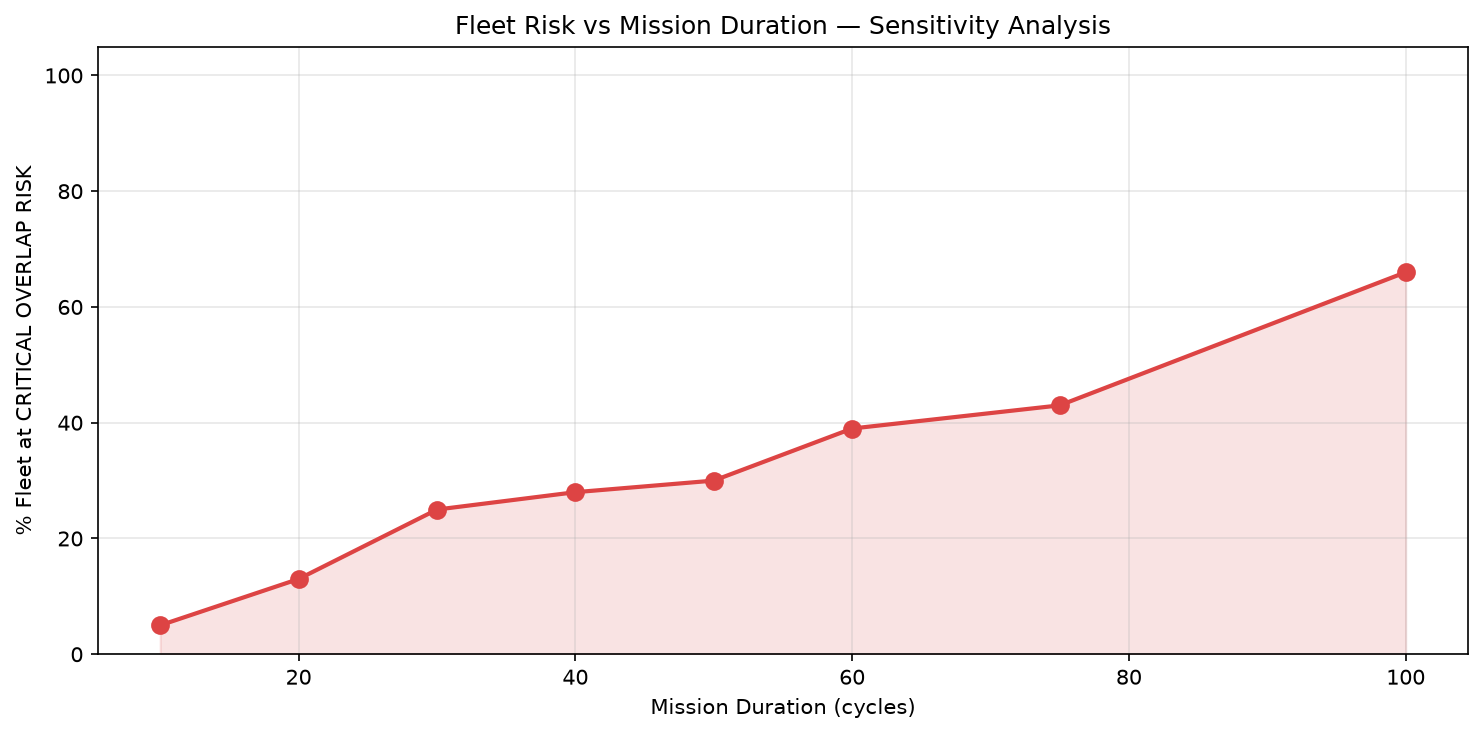

Mission Duration -> Risk %:
   10 cycles: 5.0% at risk
   20 cycles: 13.0% at risk
   30 cycles: 25.0% at risk
   40 cycles: 28.0% at risk
   50 cycles: 30.0% at risk
   60 cycles: 39.0% at risk
   75 cycles: 43.0% at risk
  100 cycles: 66.0% at risk


In [19]:
# ─── Cell 9: Mission Sensitivity Analysis ─────────────────────────────────
# How does fleet risk change as mission_duration increases?

durations = [10, 20, 30, 40, 50, 60, 75, 100]
risk_pcts = []

for dur in durations:
    tmp = apply_mission_window(test_df, dur)
    last = tmp.groupby('unit_number')['CRITICAL_OVERLAP_RISK'].last()
    risk_pcts.append(100 * last.sum() / len(last))

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(durations, risk_pcts, marker='o', color='#DD4444', linewidth=2, markersize=8)
ax.fill_between(durations, risk_pcts, alpha=0.15, color='#DD4444')
ax.set_xlabel('Mission Duration (cycles)')
ax.set_ylabel('% Fleet at CRITICAL OVERLAP RISK')
ax.set_title('Fleet Risk vs Mission Duration — Sensitivity Analysis')
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
plt.tight_layout()

plot_path = os.path.join(PLOTS_DIR, '09_mission_duration_sensitivity.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.close()

from IPython.display import Image, display
display(Image(filename=plot_path, width=800))

print('Mission Duration -> Risk %:')
for d, r in zip(durations, risk_pcts):
    print(f'  {d:3d} cycles: {r:.1f}% at risk')

---
## Pipeline Complete!

**Outputs generated:**
- `processed/train_ready.csv` — ML training set
- `processed/test_ready.csv` — ML test set  
- `processed/schema.json` — PostgreSQL-ready column schema
- `processed/scaler.pkl` — Fitted StandardScaler for inference
- `processed/plots/` — 9 diagnostic plots
- `EDA_SUMMARY.md` — Human-readable summary for the team

**Next steps for teammates:**
- **ML Team:** Use `train_ready.csv` with LSTM/GRU/XGBoost for RUL regression
- **Backend Team:** Use `schema.json` to design PostgreSQL table structures
- **API Team:** Import `apply_mission_window()` directly from `cmapss_pipeline.py`